[Font] 已检测到中文字体: SimHei
变换矩阵 A 的形状: (1024, 1024)
图像形状: (32, 32)

似然的关键洞察：似然只关心数据拟合，不关心 x 是否合理

数据拟合误差 ‖Ax - y‖₂ (L2范数):
  真实图像 x_true:  2.2254
  随机噪声 x_random: 2.0773

比值: 1.07 倍

⚠️ 随机噪声的数据拟合误差更小！
   这意味着在似然意义下，随机噪声比真实图像'更合理'
   但随机噪声显然不是一张有意义的图像


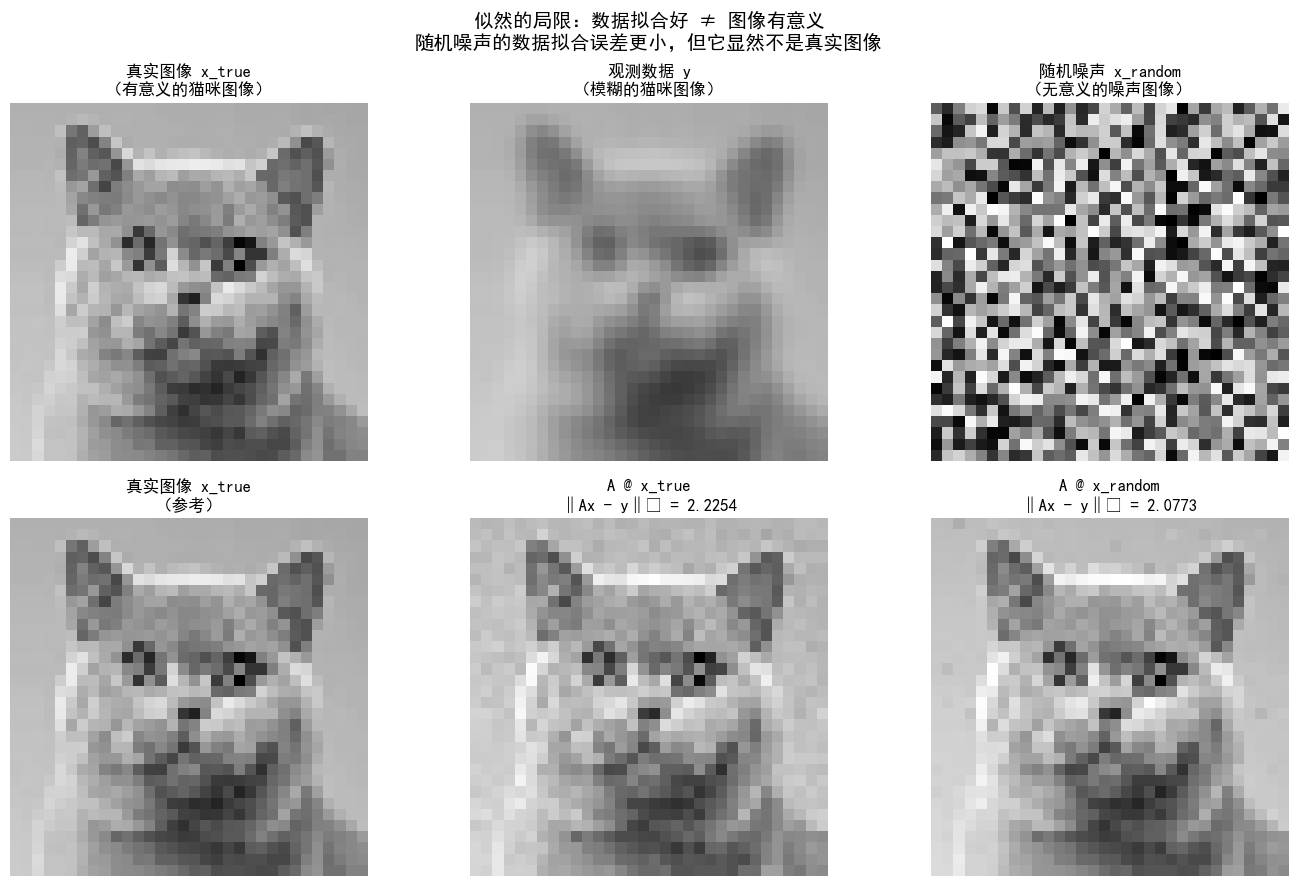


结论
似然函数 p(y|x) 只衡量'数据拟合程度'，即 ||Ax - y|| 的大小。
它无法区分：
  - 一个与数据拟合好的'有意义'图像（如真实猫咪）
  - 一个与数据拟合好的'无意义'图像（如随机噪声）

这正是不适定性的后果：
  算子 A 的信息损失使得多个不同的 x 能产生相似的 Ax
  仅靠似然无法从中选出'正确'的 x

解决方案：引入先验 p(x)
  先验编码了我们对'什么样的图像更合理'的知识
  后验 = 似然 × 先验，同时考虑数据拟合和图像合理性


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager

def _find_chinese_font():
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN',
            'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os
    import re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

# ---- 1. 加载数据 ----
# 加载变换矩阵 A (32x32)
A = np.load('transform_A.npy')
print(f"变换矩阵 A 的形状: {A.shape}")

# 加载图像
maomi_gray = np.array(Image.open('maomi_grayscale.png').convert('L')) / 255.0  # 真实图像
maomi_mohu = np.array(Image.open('maomi_mohu.png').convert('L')) / 255.0       # 观测数据（模糊）
random_gray = np.array(Image.open('random_gray.png').convert('L')) / 255.0     # 随机噪声

print(f"图像形状: {maomi_gray.shape}")

# ---- 2. 向量化图像 ----
x_true = maomi_gray.ravel()      # 真实图像 x
y_obs = maomi_mohu.ravel()       # 观测数据 y
x_random = random_gray.ravel()   # 随机噪声

# ---- 3. 计算似然（数据拟合误差）----
# 似然函数 p(y|x) ∝ exp(-||Ax - y||₂² / 2σ²)
# 数据拟合误差越小，似然越大

Ax_true = A @ x_true
Ax_random = A @ x_random

error_true = np.linalg.norm(Ax_true - y_obs)      # L2范数
error_random = np.linalg.norm(Ax_random - y_obs)  # L2范数

print("\n" + "="*60)
print("似然的关键洞察：似然只关心数据拟合，不关心 x 是否合理")
print("="*60)
print("\n数据拟合误差 ‖Ax - y‖₂ (L2范数):")
print(f"  真实图像 x_true:  {error_true:.4f}")
print(f"  随机噪声 x_random: {error_random:.4f}")
print(f"\n比值: {error_true / error_random:.2f} 倍")

if error_random < error_true:
    print("\n⚠️ 随机噪声的数据拟合误差更小！")
    print("   这意味着在似然意义下，随机噪声比真实图像'更合理'")
    print("   但随机噪声显然不是一张有意义的图像")
else:
    print("\n真实图像的数据拟合误差更小")

# ---- 4. 可视化 ----
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# 第一行：原始图像
axes[0, 0].imshow(maomi_gray, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('真实图像 x_true\n（有意义的猫咪图像）')
axes[0, 0].axis('off')

axes[0, 1].imshow(maomi_mohu, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('观测数据 y\n（模糊的猫咪图像）')
axes[0, 1].axis('off')

axes[0, 2].imshow(random_gray, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('随机噪声 x_random\n（无意义的噪声图像）')
axes[0, 2].axis('off')

# 第二行：变换结果
axes[1, 0].imshow(maomi_gray, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('真实图像 x_true\n（参考）')
axes[1, 0].axis('off')

axes[1, 1].imshow(Ax_true.reshape(32, 32), cmap='gray')
axes[1, 1].set_title(f'A @ x_true\n‖Ax - y‖₂ = {error_true:.4f}')
axes[1, 1].axis('off')

axes[1, 2].imshow(Ax_random.reshape(32, 32), cmap='gray')
axes[1, 2].set_title(f'A @ x_random\n‖Ax - y‖₂ = {error_random:.4f}')
axes[1, 2].axis('off')

plt.suptitle('似然的局限：数据拟合好 ≠ 图像有意义\n' + 
             ('随机噪声的数据拟合误差更小，但它显然不是真实图像' if error_random < error_true else ''),
             fontsize=14)
plt.tight_layout()
plt.savefig('实验1_0_似然的局限.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 5. 结论 ----
print("\n" + "="*60)
print("结论")
print("="*60)
print("似然函数 p(y|x) 只衡量'数据拟合程度'，即 ||Ax - y|| 的大小。")
print("它无法区分：")
print("  - 一个与数据拟合好的'有意义'图像（如真实猫咪）")
print("  - 一个与数据拟合好的'无意义'图像（如随机噪声）")
print("\n这正是不适定性的后果：")
print("  算子 A 的信息损失使得多个不同的 x 能产生相似的 Ax")
print("  仅靠似然无法从中选出'正确'的 x")
print("\n解决方案：引入先验 p(x)")
print("  先验编码了我们对'什么样的图像更合理'的知识")
print("  后验 = 似然 × 先验，同时考虑数据拟合和图像合理性")
